# VWAP、TWAP、そして執行のベンチマーク

執行デスクはベンチマークの算術で生き死にします。区間 VWAP、TWAP、到着価格、ベーシス
ポイントで測るスリッページ。

その中身はどれも、約定テープに対するバケット化した加重集約と、気配ストリームに対する
時点参照1つです。`time_bucket`、`vwap()`、`asof_join` が作られたのは、まさにこの形の
クエリのためでした。`vwap()` は集約関数でもウィンドウ関数でもあるので、区間の
ベンチマークも累積のベンチマークも演算子1つで賄えます。

このレシピで進めるのは次の4つです。

1. 気配ストリームからマイクロストラクチャ的に整合したテープを作る
2. 全日と30分区間の VWAP を計算する
3. 出来高の偏りで両者が離れる TWAP と対比する
4. 親注文のシミュレーション、1時間かけて執行する AAPL 5万株を、区間 VWAP と到着ミッドで
   採点する

## ここで使う用語

| 用語                | 意味 |
| ----------------- | --- |
| VWAP              | 出来高加重平均価格。市場全体が得た平均価格 |
| TWAP              | 時間加重平均価格。出来高を無視するので VWAP と必ず乖離する |
| 到着価格              | 注文がデスクに渡った瞬間の価格 |
| スリッページ            | 想定した価格と実際に得た価格との差 |
| ベーシスポイント（bp）      | 1パーセントの100分の1。執行費用はこの単位で表す |
| 親注文（parent order） | 大口注文を時間をかけて多数の小口約定として執行するときの元の注文 |
| ミッド               | ビッドとアスクの平均。「価格」を1つの数で表すときの標準的な代用値 |
| ASOF 結合           | 左の各行を、そのタイムスタンプ以前で最も新しい右の行に結合する |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

import h5i_db
from h5i_db import col, time_bucket, vwap, wavg
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_vwap"), create=True)

## 1. データ

出発点は気配です。`cu.make_quotes` はベストビッド・ベストオファーのスナップショットを
返します。最良気配が動くたびに1行です。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | 気配の時刻、昇順 |
| `symbol` | `string` | 銘柄コード |
| `bid`、`ask` | `float64` | 最良のビッドとオファー |
| `bid_size`、`ask_size` | `int64` | 各サイドの表示数量 |

In [2]:
quotes = cu.make_quotes(symbols=["AAPL", "MSFT", "NVDA"], days=3, seed=11)
print(f"quotes: {quotes.num_rows:,} rows x {quotes.num_columns} columns")
quotes.to_pandas().head()

quotes: 584,300 rows x 6 columns


,ts,symbol,bid,ask,bid_size,ask_size
0,2026-06-01 13:30:00.132754+00:00,MSFT,219.72,219.76,300,500
1,2026-06-01 13:30:00.179061+00:00,AAPL,86.28,86.29,200,800
2,2026-06-01 13:30:00.330955+00:00,AAPL,86.27,86.30,100,800
3,2026-06-01 13:30:00.334517+00:00,NVDA,256.50,256.58,100,400
4,2026-06-01 13:30:00.335023+00:00,MSFT,219.72,219.76,700,100


約定を気配で採点することに意味があるのは、約定と気配が*同じ*市場を描いているときだけです。
だからテープを独立に生成せず、気配ストリームから導きます。各約定はその時点の気配の
オファーを取るかビッドを叩き、10%はミッドで約定し、すべてのプリントに小さな取引所の遅延が
乗ります。

クックブックの既製の約定生成器と気配生成器は、始値しか共有していません。バーのレシピには
十分ですが、気配を基準にしたベンチマークには使えません。

導出したテープは1行が1プリントで、列は `ts`、`symbol`、`price`、`size`、`side` です
（`side` は `B` がオファーを取った買い手、`S` がビッドを叩いた売り手）。

In [3]:
qp = quotes.to_pandas()
rng = np.random.default_rng(17)
is_trade = rng.random(len(qp)) < 0.35
tr = qp.loc[is_trade, ["ts", "symbol", "bid", "ask"]].reset_index(drop=True)
n = len(tr)
buy = rng.random(n) < 0.5
at_mid = rng.random(n) < 0.10
px = np.where(buy, tr["ask"], tr["bid"])
px = np.where(at_mid, (tr["bid"] + tr["ask"]) / 2, px)
tr["price"] = np.round(px, 4)
tr["size"] = np.maximum(1, rng.lognormal(4.0, 1.2, n) // 100 * 100).astype("int64")
tr["side"] = np.where(buy, "B", "S")
tr["ts"] = (tr["ts"] + pd.to_timedelta(rng.uniform(0.2, 5.0, n), unit="ms")).dt.floor("us")
tr = tr.sort_values(["ts", "symbol"])[["ts", "symbol", "price", "size", "side"]]

print(f"{len(tr):,} trades derived from {len(qp):,} quotes")
tr.head()

205,032 trades derived from 584,300 quotes


,ts,symbol,price,size,side
0,2026-06-01 13:30:00.181414+00:00,AAPL,86.28,1,S
1,2026-06-01 13:30:00.338463+00:00,MSFT,219.76,1,B
2,2026-06-01 13:30:00.469201+00:00,MSFT,219.70,1,S
3,2026-06-01 13:30:00.560821+00:00,MSFT,219.72,1,B
4,2026-06-01 13:30:00.632471+00:00,MSFT,219.72,1,B


In [4]:
ts_field = pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False)
trade_schema = pa.schema(
    [ts_field, pa.field("symbol", pa.string()), pa.field("price", pa.float64()),
     pa.field("size", pa.int64()), pa.field("side", pa.string())]
)
db.create_table("trades", trade_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades", pa.Table.from_pandas(tr, preserve_index=False).cast(trade_schema))

quote_schema = pa.schema(
    [ts_field, pa.field("symbol", pa.string()), pa.field("bid", pa.float64()),
     pa.field("ask", pa.float64()), pa.field("bid_size", pa.int64()),
     pa.field("ask_size", pa.int64())]
)
db.create_table("quotes", quote_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("quotes", quotes.cast(quote_schema))

db.tables()

['quotes', 'trades']

## 2. 全日と区間の VWAP

`vwap(price, size)` は組み込みの集約関数なので、日次 VWAP は1行です。
`time_bucket('1d', ts, 'America/New_York')` の引数がセッションをニューヨークの0時で切るので、
数字は夏時間に対して安全なままです。

幅を `'30m'` に変えれば、同じ文が、執行スケジューラが狙う区間 VWAP を返します。

In [5]:
SESSION = time_bucket("1d", col("ts"), timezone="America/New_York")

day_vwap = (
    db.table("trades")
    .group_by(SESSION.alias("session"), "symbol")
    .agg(day_vwap=vwap(col("price"), col("size")), volume=col("size").sum())
    .sort(["session", "symbol"])
    .to_pandas()
)
day_vwap

,session,symbol,day_vwap,volume
0,2026-06-01 04:00:00+00:00,AAPL,85.918305,1180224
1,2026-06-01 04:00:00+00:00,MSFT,220.912739,1590721
2,2026-06-01 04:00:00+00:00,NVDA,257.029176,1625935
3,2026-06-02 04:00:00+00:00,AAPL,85.606389,1840939
4,2026-06-02 04:00:00+00:00,MSFT,218.861272,1833542
5,2026-06-02 04:00:00+00:00,NVDA,260.448508,1565546
6,2026-06-03 04:00:00+00:00,AAPL,85.956578,1733637
7,2026-06-03 04:00:00+00:00,MSFT,222.525500,1923451
8,2026-06-03 04:00:00+00:00,NVDA,259.877400,1547802


In [6]:
ivwap = (
    db.table("trades")
    .group_by(time_bucket("30m", col("ts")).alias("interval_start"), "symbol")
    .agg(interval_vwap=vwap(col("price"), col("size")), volume=col("size").sum())
    .sort(["interval_start", "symbol"])
    .to_pandas()
)
ivwap.head(6)

,interval_start,symbol,interval_vwap,volume
0,2026-06-01 13:30:00+00:00,AAPL,86.140423,283576
1,2026-06-01 13:30:00+00:00,MSFT,221.017213,351369
2,2026-06-01 13:30:00+00:00,NVDA,257.029127,344659
3,2026-06-01 14:00:00+00:00,AAPL,85.895450,182930
4,2026-06-01 14:00:00+00:00,MSFT,221.340027,245497
5,2026-06-01 14:00:00+00:00,NVDA,256.175272,264951


## 3. TWAP と VWAP

TWAP はどの1分にも同じ重みを置きます。VWAP は出来高で重み付けします。出来高がU字型なら
VWAP は寄りと引けに重みを集めるので、両端付近の価格が日中の真ん中と違えば、2つの
ベンチマークは離れます。

ここでは1分足の終値から TWAP を組み立て、セッションごとの乖離をベーシスポイントで測ります。
すでに集約になっているフレームをさらに集約すると入れ子になるだけなので、CTE は勝手に
書き上がります。

In [7]:
bars_1m = (
    db.table("trades")
    .group_by(time_bucket("1m", col("ts")).alias("bar"), "symbol")
    .agg(close=col("price").last("ts"))
)

twap = (
    bars_1m.group_by(
        time_bucket("1d", col("bar"), timezone="America/New_York").alias("session"),
        "symbol",
    )
    .agg(twap=col("close").mean())
    .sort(["session", "symbol"])
    .to_pandas()
)

bench = day_vwap.merge(twap, on=["session", "symbol"])
bench["vwap_minus_twap_bps"] = (bench["day_vwap"] / bench["twap"] - 1) * 1e4
bench[["session", "symbol", "day_vwap", "twap", "vwap_minus_twap_bps"]]

,session,symbol,day_vwap,twap,vwap_minus_twap_bps
0,2026-06-01 04:00:00+00:00,AAPL,85.918305,85.934167,-1.845773
1,2026-06-01 04:00:00+00:00,MSFT,220.912739,220.987436,-3.380122
2,2026-06-01 04:00:00+00:00,NVDA,257.029176,256.817500,8.242270
3,2026-06-02 04:00:00+00:00,AAPL,85.606389,85.589564,1.965762
4,2026-06-02 04:00:00+00:00,MSFT,218.861272,218.877756,-0.753135
5,2026-06-02 04:00:00+00:00,NVDA,260.448508,261.066885,-23.686533
6,2026-06-03 04:00:00+00:00,AAPL,85.956578,85.831872,14.529083
7,2026-06-03 04:00:00+00:00,MSFT,222.525500,222.934577,-18.349630
8,2026-06-03 04:00:00+00:00,NVDA,259.877400,259.437795,16.944529


数 bps の上下は、寄りと引けの厚い出来高が日中平均より上で出たか下で出たかだけで決まります。

累積で見ると仕組みが目に見えます。`vwap()` は*ウィンドウ*関数としても動くので、累積 VWAP に
`sum(pv)/sum(v)` の手作業は要りません。

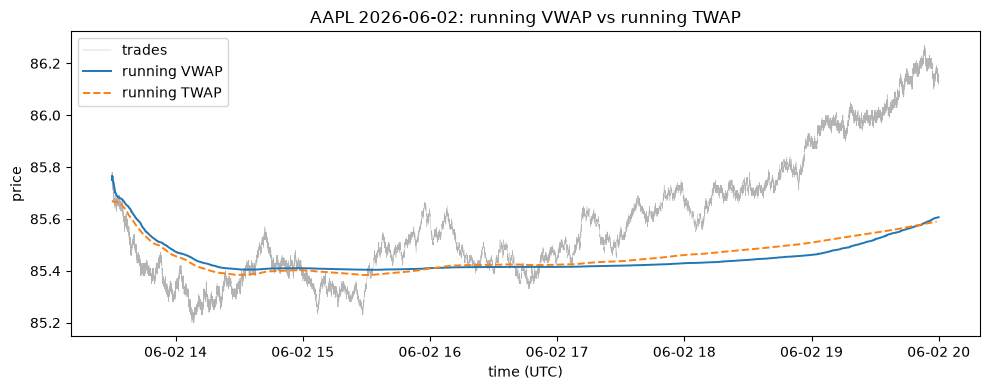

In [8]:
def aapl_window(t_lo: str, t_hi: str):
    return db.table("trades").filter(
        col("symbol") == "AAPL", col("ts") >= t_lo, col("ts") < t_hi
    )


session = aapl_window("2026-06-02T00:00:00Z", "2026-06-03T00:00:00Z")

run = session.select(
    "ts", "price", running_vwap=vwap(col("price"), col("size")).over(order_by="ts")
).sort("ts").to_pandas()

closes_1m = (
    session.group_by(time_bucket("1m", col("ts")).alias("bar"))
    .agg(close=col("price").last("ts"))
    .sort("bar")
    .to_pandas()
)
closes_1m["running_twap"] = closes_1m["close"].expanding().mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(run["ts"], run["price"], lw=0.3, color="0.7", label="trades")
ax.plot(run["ts"], run["running_vwap"], lw=1.4, label="running VWAP")
ax.plot(closes_1m["bar"], closes_1m["running_twap"], lw=1.4, ls="--", label="running TWAP")
ax.set_title("AAPL 2026-06-02: running VWAP vs running TWAP")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("price")
ax.legend()
fig.tight_layout()

## 4. 親注文を採点する

デスクは 2026-06-02 の 14:00〜15:00 UTC（ニューヨーク 10:00〜11:00）に AAPL を5万株買います。
注文は POV 型で、オファーを取りにいく攻撃的なフローに対しておおむね一定の参加率で執行します。

テープから約定をシミュレートし、`fills` テーブルとして保存します。到着価格は標準的なやり方で
記録します。注文受領時点の気配ミッドを、1行の `asof_join` で取ってくるのです。

In [9]:
t0, t1 = pd.Timestamp("2026-06-02 14:00", tz="UTC"), pd.Timestamp("2026-06-02 15:00", tz="UTC")
win = tr[(tr["symbol"] == "AAPL") & (tr["ts"] >= t0) & (tr["ts"] < t1)]
liftable = win[win["side"] == "B"]  # prints where an aggressive buyer paid the offer

target = 50_000
pov = target / liftable["size"].sum()
fills = liftable[["ts", "symbol", "price"]].copy()
fills["size"] = np.maximum(1, (liftable["size"] * pov).round()).astype("int64")
fills.iloc[-1, fills.columns.get_loc("size")] += target - fills["size"].sum()

fill_schema = pa.schema(
    [ts_field, pa.field("symbol", pa.string()), pa.field("price", pa.float64()),
     pa.field("size", pa.int64())]
)
db.create_table("fills", fill_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("fills", pa.Table.from_pandas(fills, preserve_index=False).cast(fill_schema))
print(f"{len(fills):,} fills, {fills['size'].sum():,} shares, "
      f"~{pov:.0%} of aggressive buy volume")

3,212 fills, 50,000 shares, ~21% of aggressive buy volume


`asof_join` は保存済みのテーブル名を取るので、まず注文受領前後の気配の窓を、それ自体の
小さなテーブルとして切り出します。デスクは後の TCA レビューのために、まさにこういう窓を
保存します。そのうえで1行の親注文をそこに結合します。

念のため、asof の参照結果が「14:00 以前で最新の気配」という明示的な時点クエリと一致することも
確認します。

In [10]:
qwin = (
    db.table("quotes")
    .filter(
        col("symbol") == "AAPL",
        col("ts") >= "2026-06-02T13:50:00Z",
        col("ts") < "2026-06-02T14:10:00Z",
    )
    .sort("ts")
    .to_arrow()
)
db.create_table("quotes_arrival", quote_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("quotes_arrival", qwin.cast(quote_schema))

parent = pa.table(
    {"ts": pa.array([t0], type=pa.timestamp("us", tz="UTC")), "symbol": ["AAPL"]}
).cast(pa.schema([ts_field, pa.field("symbol", pa.string())]))
db.create_table("parent", parent.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("parent", parent)

MID = (col("bid") + col("ask")) / 2

arrival = (
    db.table("parent")
    .join_asof(db.table("quotes_arrival"), on="ts", by="symbol")
    .select("ts", "symbol", quote_ts=col("ts_right"), arrival_mid=MID)
    .to_pandas()
)

direct = (
    db.table("quotes")
    .filter(col("symbol") == "AAPL", col("ts") <= "2026-06-02T14:00:00Z")
    .sort("ts", descending=True)
    .limit(1)
    .select(mid=MID)
    .to_pandas()["mid"][0]
)
assert np.isclose(arrival["arrival_mid"][0], direct)
arrival

,ts,symbol,quote_ts,arrival_mid
0,2026-06-02 14:00:00+00:00,AAPL,2026-06-02 13:59:59.967882+00:00,85.33


`asof_join` は 14:00:00 以前で最後の気配を拾いました。`quote_ts` はその気配がどれだけ古かった
かを示し、右側でぶつかった列には `_right` が付きます。

では採点表です。約定 VWAP を区間 VWAP と、そして到着価格と比べます。

In [11]:
VWAP = vwap(col("price"), col("size"))
hour = aapl_window("2026-06-02T14:00:00Z", "2026-06-02T15:00:00Z")

fill_vwap = db.table("fills").select(v=VWAP).to_pandas()["v"][0]
mkt_vwap = hour.select(v=VWAP).to_pandas()["v"][0]
arrival_mid = arrival["arrival_mid"][0]

print(f"arrival mid          : {arrival_mid:.4f}")
print(f"interval VWAP (14-15): {mkt_vwap:.4f}")
print(f"fill VWAP            : {fill_vwap:.4f}")
print(f"slippage vs interval VWAP: {(fill_vwap / mkt_vwap - 1) * 1e4:+.2f} bps")
print(f"slippage vs arrival mid  : {(fill_vwap / arrival_mid - 1) * 1e4:+.2f} bps")

arrival mid          : 85.3300
interval VWAP (14-15): 85.3533
fill VWAP            : 85.3554
slippage vs interval VWAP: +0.25 bps
slippage vs arrival mid  : +2.98 bps


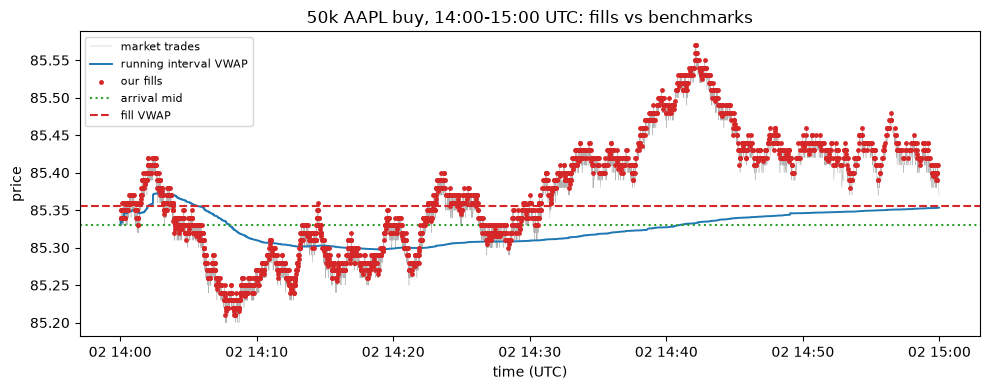

In [12]:
fp = fills
mkt = hour.select("ts", "price", running_vwap=VWAP.over(order_by="ts")).sort("ts").to_pandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mkt["ts"], mkt["price"], lw=0.3, color="0.7", label="market trades")
ax.plot(mkt["ts"], mkt["running_vwap"], lw=1.4, label="running interval VWAP")
ax.scatter(fp["ts"], fp["price"], s=6, color="tab:red", label="our fills", zorder=3)
ax.axhline(arrival_mid, ls=":", color="tab:green", label="arrival mid")
ax.axhline(fill_vwap, ls="--", color="tab:red", label="fill VWAP")
ax.set_title("50k AAPL buy, 14:00-15:00 UTC: fills vs benchmarks")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("price")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()

オファーを取ると区間 VWAP に対しておよそ半スプレッドぶん払います。成行寄りの POV
スケジュールなら、まさにこうなるはずです。到着価格に対するスリッページには、そのうえに
1時間ぶんの価格ドリフトが乗ります。実装ショートフォールと呼ばれる量です。

## 5. `vwap` と kdb 流の `wavg` は同じ統計量

q から移ってきた方へ。`w wavg x` は重みが先です。h5i-db は両方の綴りを備えています。

In [13]:
eq = db.table("fills").select(
    vwap=vwap(col("price"), col("size")),
    wavg=wavg(col("size"), col("price")),
).to_pandas()
assert np.isclose(eq["vwap"][0], eq["wavg"][0])
eq

,vwap,wavg
0,85.355427,85.355427


## まとめ

- `vwap(price, size)` は集約関数として働き、`time_bucket` と組めば日次・区間の VWAP に
  なります。ウィンドウ関数としても働き、累積 VWAP になります。どちらでも
  `sum(pv)/sum(v)` の足場は要りません。`wavg(w, x)` は同じ統計量の kdb 流の綴りです。
- 1分足の終値からの TWAP は CTE 1つぶんの距離です。VWAP と TWAP の乖離はセッションごとの
  bps として出てきて、その正体はU字型の出来高です。
- 到着価格は、保存した気配の窓に対する1行の `asof_join` です。明示的な時点クエリで
  裏取りするのも安上がりですし、お金が動くベンチマークでは持っておきたい習慣です。
- ベンチマークに意味があるのは、テープが整合しているときだけです。気配を基準にした数字を
  信じる前に、約定を気配ストリームから導くか、気配に照らして検証してください。

In [14]:
db.close()